# Concordance Evaluator (Notebook)

Visual-only evaluator run inside the notebook:
- correction field maps and sampled correction magnitude
- rematch metrics before/after for both signs
- fixed-pair metrics before/after for both signs
- residual scatter/CDF/vector plots for the chosen sign


In [11]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.coordinates import SkyCoord, search_around_sky
from astropy.wcs import WCS
from astropy import units as u
from scipy.ndimage import maximum_filter, zoom

plt.rcParams['figure.figsize'] = (7, 5)
plt.rcParams['image.origin'] = 'lower'
plt.rcParams['axes.grid'] = False


In [12]:
# Paths + controls
cwd = Path.cwd().resolve()
if (cwd / 'models/astrometry').exists():
    REPO_ROOT = cwd
elif cwd.name == 'astrometry' and (cwd / 'inspect_concordance_fits.ipynb').exists():
    REPO_ROOT = cwd.parents[1]
else:
    REPO_ROOT = Path('/home/shemmati/JAISP')

candidate_fits = [
    REPO_ROOT / 'concordance_ecdfs_50ep_allbands.fits',
    REPO_ROOT / 'concordance_ecdfs.fits',
]


def _count_rubin_bands_in_fits(path):
    if not path.exists():
        return -1
    bands = set()
    with fits.open(path) as hdul:
        for hdu in hdul[1:]:
            parts = hdu.name.lower().split('.')
            if len(parts) == 3 and parts[1] in {'u', 'g', 'r', 'i', 'z', 'y'} and parts[2] in {'dra', 'dde'}:
                bands.add(parts[1])
    return len(bands)

existing = [pp for pp in candidate_fits if pp.exists()]
if not existing:
    FITS_PATH = candidate_fits[-1]
else:
    FITS_PATH = max(existing, key=_count_rubin_bands_in_fits)

TILE_ID = 'tile_x00000_y00000'
RUBIN_BAND = 'r'
EUCLID_BAND = 'VIS'
EVAL_SIGNS = [+1.0, -1.0]
PLOT_SIGN = None  # set to +1.0 or -1.0 to override auto-best
MAX_SEP_ARCSEC = 0.1
CLIP_SIGMA = 3.5

DETECT_NSIGMA = 10.0
DETECT_TOP = 5000
DETECT_LOCAL_BOX = 128
DETECT_BORDER = 10
DETECT_REFINE_R = 5


In [13]:
# Self-contained helpers (no external evaluator script)

RUBIN_BAND_ORDER = ['u', 'g', 'r', 'i', 'z', 'y']


def _extract_npz_scalar(obj):
    if isinstance(obj, np.ndarray) and obj.shape == ():
        return obj.item()
    return obj


def _decode_header_string(value) -> str:
    v = _extract_npz_scalar(value)
    if isinstance(v, bytes):
        return v.decode('utf-8')
    return str(v)


def _parse_fits_header_string(header_text: str) -> fits.Header:
    text = str(header_text).replace('\x00', '')
    if '\n' in text:
        try:
            return fits.Header.fromstring(text, sep='\n')
        except Exception:
            return fits.Header.fromstring(text, sep='')
    try:
        return fits.Header.fromstring(text, sep='')
    except Exception:
        return fits.Header.fromstring(text, sep='\n')


def _wcs_from_rubin_hdr_dict(hdr_dict):
    hdr = fits.Header()
    for k, v in hdr_dict.items():
        try:
            hdr[k] = v
        except Exception:
            hdr[str(k)] = str(v)
    w = WCS(hdr)
    if not w.has_celestial:
        raise ValueError('Rubin tile WCS header has no celestial axes.')
    return w


def _load_rubin_tile_for_autocat(path: str, band_key: str):
    band = band_key.lower().replace('rubin_', '')
    idx = RUBIN_BAND_ORDER.index(band)
    d = np.load(path, allow_pickle=True)
    img = np.asarray(d['img'][idx], dtype=float)
    wcs_hdr_obj = _extract_npz_scalar(d['wcs_hdr'])
    wcs = _wcs_from_rubin_hdr_dict(wcs_hdr_obj)
    return img, wcs


def _load_euclid_tile_for_autocat(path: str, band_key: str = 'VIS'):
    band = band_key.upper()
    d = np.load(path, allow_pickle=False)
    img = np.asarray(d[f'img_{band}'], dtype=float)
    hdr = _parse_fits_header_string(_decode_header_string(d[f'wcs_{band}']))
    wcs = WCS(hdr)
    if not wcs.has_celestial:
        raise ValueError('Euclid tile WCS header has no celestial axes.')
    return img, wcs


def _find_peaks(img, nsigma=10.0, border=10, top=5000, local_box=128):
    data = np.nan_to_num(img, nan=-np.inf)
    ny, nx = data.shape
    b = max(4, int(local_box))

    py = (-ny) % b
    px = (-nx) % b
    data_p = np.pad(data, ((0, py), (0, px)), mode='edge') if (py or px) else data
    Ny, Nx = data_p.shape
    by, bx = Ny // b, Nx // b

    blocks = data_p.reshape(by, b, bx, b)
    m_blk = np.nanmedian(blocks, axis=(1, 3))
    mad_blk = np.nanmedian(np.abs(blocks - m_blk[:, None, :, None]), axis=(1, 3))
    s_blk = 1.4826 * mad_blk

    m = zoom(m_blk, (b, b), order=1)[:Ny, :Nx][:ny, :nx]
    s = zoom(s_blk, (b, b), order=1)[:Ny, :Nx][:ny, :nx]
    thr = m + float(nsigma) * s

    local_max = maximum_filter(data, size=3) == data
    mask = (data > thr) & local_max & np.isfinite(data)

    if border > 0:
        mask[:border, :] = False
        mask[-border:, :] = False
        mask[:, :border] = False
        mask[:, -border:] = False

    ys, xs = np.where(mask)
    if xs.size == 0:
        return np.array([], dtype=float), np.array([], dtype=float)

    vals = data[ys, xs]
    order = np.argsort(vals)[::-1]
    order = order[: int(top)] if top is not None else order
    return xs[order].astype(float), ys[order].astype(float)


def _parabolic_subpixel_1d(fm1, f0, fp1):
    denom = fm1 - 2.0 * f0 + fp1
    if denom == 0 or not np.isfinite(denom):
        return 0.0
    dx = 0.5 * (fm1 - fp1) / denom
    if not np.isfinite(dx):
        return 0.0
    return float(np.clip(dx, -0.75, 0.75))


def _refine_centroids(img, xs, ys, r=5):
    if len(xs) == 0:
        return xs, ys
    outx, outy = [], []
    ny, nx = img.shape
    data = np.nan_to_num(img, nan=-np.inf)

    for x0, y0 in zip(xs, ys):
        ix, iy = int(round(float(x0))), int(round(float(y0)))
        y1, y2 = max(0, iy - r), min(ny, iy + r + 1)
        x1, x2 = max(0, ix - r), min(nx, ix + r + 1)
        patch = data[y1:y2, x1:x2]
        if patch.size < 9 or not np.any(np.isfinite(patch)):
            outx.append(float(x0)); outy.append(float(y0)); continue

        py, px = np.unravel_index(np.argmax(patch), patch.shape)
        gy, gx = y1 + py, x1 + px

        if 0 < gx < (nx - 1):
            dx = _parabolic_subpixel_1d(data[gy, gx - 1], data[gy, gx], data[gy, gx + 1])
        else:
            dx = 0.0
        if 0 < gy < (ny - 1):
            dy = _parabolic_subpixel_1d(data[gy - 1, gx], data[gy, gx], data[gy + 1, gx])
        else:
            dy = 0.0

        outx.append(float(gx) + dx)
        outy.append(float(gy) + dy)

    return np.asarray(outx, dtype=float), np.asarray(outy, dtype=float)


def _detect_sources_to_sky(img, wcs, nsigma=10.0, top=5000, local_box=128, border=10, refine_r=5):
    xs, ys = _find_peaks(img, nsigma=nsigma, border=border, top=top, local_box=local_box)
    xs, ys = _refine_centroids(img, xs, ys, r=refine_r)
    if len(xs) == 0:
        return SkyCoord(ra=np.array([]) * u.deg, dec=np.array([]) * u.deg, frame='icrs'), xs, ys
    sky = SkyCoord.from_pixel(xs, ys, wcs, origin=0)
    return sky, xs, ys


def _get_hdu_data_by_name(hdul, extname):
    wanted = extname.upper()
    for hdu in hdul:
        if hdu.name.upper() == wanted:
            if hdu.data is None:
                raise ValueError(f'HDU {extname} has no data.')
            return np.asarray(hdu.data, dtype=float), hdu.header
    raise KeyError(f'Extension {extname} not found.')


def _bilinear_sample(data, x, y):
    h, w = data.shape
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    out = np.full(x.shape, np.nan, dtype=float)

    valid = np.isfinite(x) & np.isfinite(y) & (x >= 0) & (y >= 0) & (x <= (w - 1)) & (y <= (h - 1))
    if not np.any(valid):
        return out

    xv = x[valid]; yv = y[valid]
    x0 = np.floor(xv).astype(int); y0 = np.floor(yv).astype(int)
    x1 = np.clip(x0 + 1, 0, w - 1); y1 = np.clip(y0 + 1, 0, h - 1)
    wx = xv - x0; wy = yv - y0

    f00 = data[y0, x0]; f01 = data[y0, x1]
    f10 = data[y1, x0]; f11 = data[y1, x1]
    outv = ((1.0 - wx) * (1.0 - wy) * f00 + wx * (1.0 - wy) * f01 + (1.0 - wx) * wy * f10 + wx * wy * f11)
    out[valid] = outv
    return out


def _map_xy_from_vis_xy(x_vis, y_vis, map_w, map_h, full_w, full_h, xy_origin):
    x0 = np.asarray(x_vis, dtype=float) - float(xy_origin)
    y0 = np.asarray(y_vis, dtype=float) - float(xy_origin)
    x_map = ((x0 + 0.5) / float(full_w)) * float(map_w) - 0.5
    y_map = ((y0 + 0.5) / float(full_h)) * float(map_h) - 0.5
    return x_map, y_map


def _apply_concordance_to_catalog(cand_ra_deg, cand_dec_deg, dra_arcsec, ddec_arcsec, apply_sign):
    dec_rad = np.deg2rad(cand_dec_deg)
    cosdec = np.cos(dec_rad)
    eps = 1e-12
    safe = np.where(np.abs(cosdec) > eps, cosdec, np.sign(cosdec) * eps + (cosdec == 0) * eps)
    d_ra_deg = apply_sign * (dra_arcsec / (3600.0 * safe))
    d_dec_deg = apply_sign * (ddec_arcsec / 3600.0)
    return cand_ra_deg + d_ra_deg, cand_dec_deg + d_dec_deg


In [14]:
# Run the evaluator logic in-notebook
with fits.open(FITS_PATH) as hdul:
    dra_name = f'{TILE_ID}.{RUBIN_BAND}.DRA'
    dde_name = f'{TILE_ID}.{RUBIN_BAND}.DDE'
    dra_map, dra_hdr = _get_hdu_data_by_name(hdul, dra_name)
    dde_map, _ = _get_hdu_data_by_name(hdul, dde_name)

rubin_tile = REPO_ROOT / f'data/rubin_tiles_ecdfs/{TILE_ID}.npz'
euclid_tile = REPO_ROOT / f'data/euclid_tiles_ecdfs/{TILE_ID}_euclid.npz'
rubin_img, rubin_wcs = _load_rubin_tile_for_autocat(str(rubin_tile), RUBIN_BAND)
eu_img, eu_wcs = _load_euclid_tile_for_autocat(str(euclid_tile), EUCLID_BAND)

ref_sky, _, _ = _detect_sources_to_sky(
    img=eu_img,
    wcs=eu_wcs,
    nsigma=DETECT_NSIGMA,
    top=DETECT_TOP,
    local_box=DETECT_LOCAL_BOX,
    border=DETECT_BORDER,
    refine_r=DETECT_REFINE_R,
)
cand_sky, _, _ = _detect_sources_to_sky(
    img=rubin_img,
    wcs=rubin_wcs,
    nsigma=DETECT_NSIGMA,
    top=DETECT_TOP,
    local_box=DETECT_LOCAL_BOX,
    border=DETECT_BORDER,
    refine_r=DETECT_REFINE_R,
)

cand_x_vis, cand_y_vis = eu_wcs.world_to_pixel(cand_sky)
map_h, map_w = dra_map.shape
dstep = int(dra_hdr.get('DSTEP', 8))
x_map, y_map = _map_xy_from_vis_xy(
    x_vis=np.asarray(cand_x_vis, dtype=float),
    y_vis=np.asarray(cand_y_vis, dtype=float),
    map_w=map_w,
    map_h=map_h,
    full_w=map_w * dstep,
    full_h=map_h * dstep,
    xy_origin=0,
)
dra_s = _bilinear_sample(dra_map, x_map, y_map)
dde_s = _bilinear_sample(dde_map, x_map, y_map)
valid = np.isfinite(dra_s) & np.isfinite(dde_s)
corr_mag_mas = 1000.0 * np.hypot(dra_s[valid], dde_s[valid])

ref_sky_eval = ref_sky
cand_before_sky = cand_sky[valid]
cand_x = np.asarray(cand_x_vis, dtype=float)[valid]
cand_y = np.asarray(cand_y_vis, dtype=float)[valid]


def greedy_match(ref_sky_local, cand_sky_local, max_sep_arcsec):
    idx_ref, idx_cand, sep2d, _ = search_around_sky(ref_sky_local, cand_sky_local, max_sep_arcsec * u.arcsec)
    if len(idx_ref) == 0:
        return np.array([], int), np.array([], int), np.array([], float)
    sep = sep2d.to(u.arcsec).value
    order = np.argsort(sep)
    used_r = np.zeros(len(ref_sky_local), dtype=bool)
    used_c = np.zeros(len(cand_sky_local), dtype=bool)
    ri, ci, so = [], [], []
    for k in order:
        r = int(idx_ref[k]); c = int(idx_cand[k])
        if used_r[r] or used_c[c]:
            continue
        used_r[r] = True; used_c[c] = True
        ri.append(r); ci.append(c); so.append(float(sep[k]))
    return np.asarray(ri, int), np.asarray(ci, int), np.asarray(so, float)


def offsets_mas(ref_sub, cand_sub):
    cosd = np.cos(np.deg2rad(ref_sub.dec.deg))
    dra = (cand_sub.ra.deg - ref_sub.ra.deg) * 3600.0 * 1000.0 * cosd
    ddec = (cand_sub.dec.deg - ref_sub.dec.deg) * 3600.0 * 1000.0
    return np.asarray(dra, float), np.asarray(ddec, float)


def robust_keep(dra, ddec, clip_sigma):
    if dra.size == 0:
        return np.zeros(0, dtype=bool)
    mra = float(np.median(dra)); mde = float(np.median(ddec))
    sra = float(1.4826 * np.median(np.abs(dra - mra)))
    sde = float(1.4826 * np.median(np.abs(ddec - mde)))
    if not np.isfinite(sra) or sra <= 0:
        sra = float(np.std(dra) + 1e-9)
    if not np.isfinite(sde) or sde <= 0:
        sde = float(np.std(ddec) + 1e-9)
    return (np.abs(dra - mra) < clip_sigma * sra) & (np.abs(ddec - mde) < clip_sigma * sde)


def summarize(dra, ddec):
    if dra.size == 0:
        return {'n': 0, 'median': np.nan, 'p68c': np.nan, 'rms': np.nan}
    r = np.hypot(dra, ddec)
    mdra = float(np.median(dra)); mdde = float(np.median(ddec))
    rc = np.hypot(dra - mdra, ddec - mdde)
    return {'n': int(dra.size), 'median': float(np.hypot(mdra, mdde)), 'p68c': float(np.quantile(rc, 0.68)), 'rms': float(np.sqrt(np.mean(r * r)))}


def eval_rematch(cand_after_sky):
    ri, ci, sep = greedy_match(ref_sky_eval, cand_after_sky, MAX_SEP_ARCSEC)
    if len(ri) == 0:
        z = summarize(np.array([]), np.array([]))
        return {'ri': ri, 'ci': ci, 'sep': sep, 'dra': np.array([]), 'ddec': np.array([]), 'r': np.array([]), 'all': z, 'clipped': z}
    dra, ddec = offsets_mas(ref_sky_eval[ri], cand_after_sky[ci])
    keep = robust_keep(dra, ddec, CLIP_SIGMA)
    return {'ri': ri, 'ci': ci, 'sep': sep, 'dra': dra, 'ddec': ddec, 'r': np.hypot(dra, ddec), 'all': summarize(dra, ddec), 'clipped': summarize(dra[keep], ddec[keep])}


def eval_fixed_pairs(cand_after_sky):
    ri, ci, sep = greedy_match(ref_sky_eval, cand_before_sky, MAX_SEP_ARCSEC)
    if len(ri) == 0:
        z = summarize(np.array([]), np.array([]))
        return {'ri': ri, 'ci': ci, 'sep': sep, 'before_all': z, 'before_clip': z, 'after_all': z, 'after_clip': z, 'delta_clip': {'median': np.nan, 'p68c': np.nan, 'rms': np.nan}}
    dra_b, ddec_b = offsets_mas(ref_sky_eval[ri], cand_before_sky[ci])
    dra_a, ddec_a = offsets_mas(ref_sky_eval[ri], cand_after_sky[ci])
    keep = robust_keep(dra_b, ddec_b, CLIP_SIGMA)
    b_all = summarize(dra_b, ddec_b)
    b_clip = summarize(dra_b[keep], ddec_b[keep])
    a_all = summarize(dra_a, ddec_a)
    a_clip = summarize(dra_a[keep], ddec_a[keep])
    return {'ri': ri, 'ci': ci, 'sep': sep, 'before_all': b_all, 'before_clip': b_clip, 'after_all': a_all, 'after_clip': a_clip, 'delta_clip': {'median': a_clip['median'] - b_clip['median'], 'p68c': a_clip['p68c'] - b_clip['p68c'], 'rms': a_clip['rms'] - b_clip['rms']}}


baseline = eval_rematch(cand_before_sky)
results_by_sign = {}
for s in EVAL_SIGNS:
    ra_corr, dec_corr = _apply_concordance_to_catalog(
        cand_ra_deg=np.asarray(cand_before_sky.ra.deg, float),
        cand_dec_deg=np.asarray(cand_before_sky.dec.deg, float),
        dra_arcsec=dra_s[valid],
        ddec_arcsec=dde_s[valid],
        apply_sign=float(s),
    )
    cand_after = SkyCoord(ra=ra_corr * u.deg, dec=dec_corr * u.deg, frame='icrs')
    results_by_sign[float(s)] = {'after_sky': cand_after, 'rematch': eval_rematch(cand_after), 'fixed': eval_fixed_pairs(cand_after)}


def sign_score(sign):
    r = results_by_sign[float(sign)]
    f = r['fixed']['after_clip']
    rm = r['rematch']['clipped']
    nfix = r['fixed']['before_clip']['n']
    return (float(f['p68c']), float(f['median']), -int(nfix), float(rm['p68c']), float(rm['median']), -int(r['rematch']['all']['n']))


BEST_SIGN = min([float(s) for s in EVAL_SIGNS], key=sign_score)
ACTIVE_SIGN = float(PLOT_SIGN) if PLOT_SIGN is not None else BEST_SIGN
active = results_by_sign[ACTIVE_SIGN]

dra_b = baseline['dra']; ddec_b = baseline['ddec']; r_b = baseline['r']; ci_b = baseline['ci']
dra_a = active['rematch']['dra']; ddec_a = active['rematch']['ddec']; r_a = active['rematch']['r']; ci_a = active['rematch']['ci']


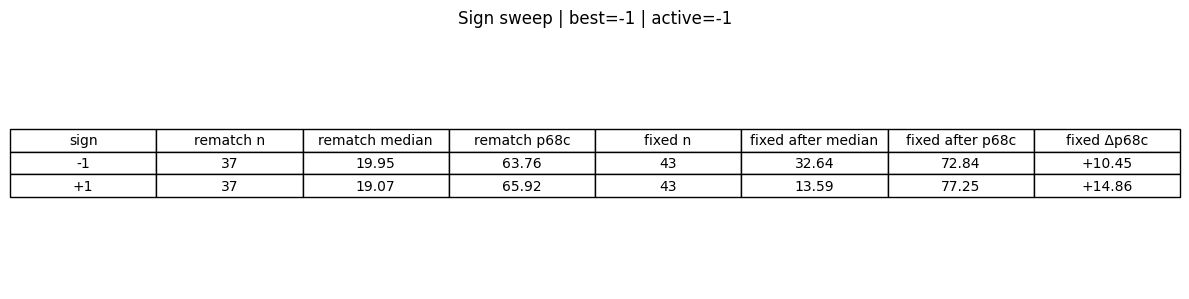

In [15]:
# Sign comparison (visual summary)
rows = []
for s in sorted(results_by_sign.keys()):
    rem = results_by_sign[s]['rematch']
    fix = results_by_sign[s]['fixed']
    rows.append([
        f'{s:+.0f}',
        f"{rem['all']['n']}",
        f"{rem['all']['median']:.2f}",
        f"{rem['clipped']['p68c']:.2f}",
        f"{fix['before_clip']['n']}",
        f"{fix['after_clip']['median']:.2f}",
        f"{fix['after_clip']['p68c']:.2f}",
        f"{fix['delta_clip']['p68c']:+.2f}",
    ])

col_labels = ['sign', 'rematch n', 'rematch median', 'rematch p68c', 'fixed n', 'fixed after median', 'fixed after p68c', 'fixed Δp68c']
fig, ax = plt.subplots(figsize=(12, 2.2 + 0.45 * len(rows)))
ax.axis('off')
tbl = ax.table(cellText=rows, colLabels=col_labels, loc='center', cellLoc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.0, 1.3)
ax.set_title(f'Sign sweep | best={BEST_SIGN:+.0f} | active={ACTIVE_SIGN:+.0f}', pad=10)
plt.tight_layout()
plt.show()


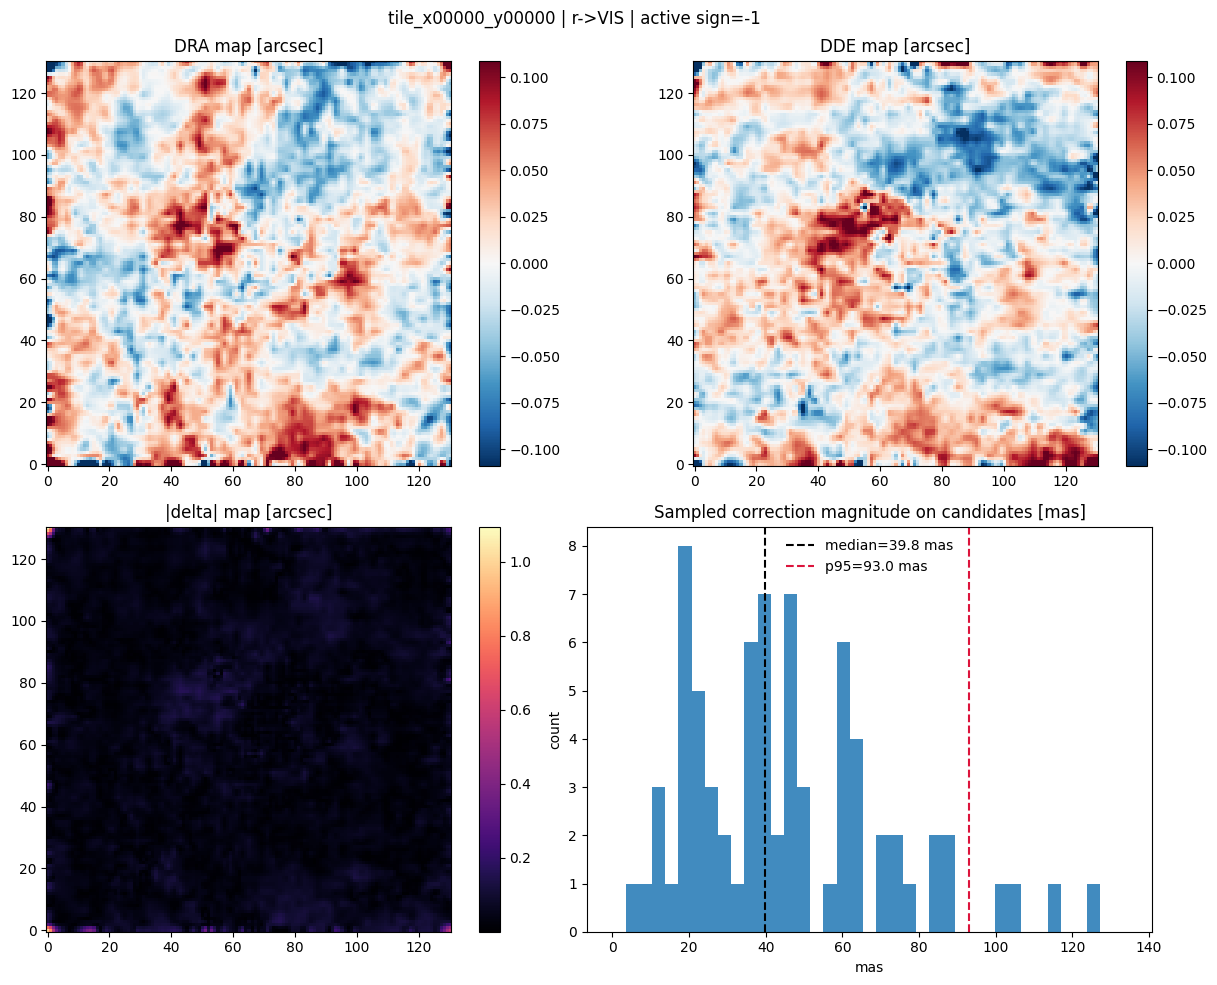

In [16]:
# Correction field + sampled correction magnitude
mag_map = np.hypot(dra_map, dde_map)
q = float(np.nanpercentile(np.abs(np.concatenate([dra_map.ravel(), dde_map.ravel()])), 99))
q = max(q, 1e-6)

fig, ax = plt.subplots(2, 2, figsize=(13, 10))
im0 = ax[0, 0].imshow(dra_map, cmap='RdBu_r', vmin=-q, vmax=q)
ax[0, 0].set_title('DRA map [arcsec]')
plt.colorbar(im0, ax=ax[0, 0], fraction=0.046)
im1 = ax[0, 1].imshow(dde_map, cmap='RdBu_r', vmin=-q, vmax=q)
ax[0, 1].set_title('DDE map [arcsec]')
plt.colorbar(im1, ax=ax[0, 1], fraction=0.046)
im2 = ax[1, 0].imshow(mag_map, cmap='magma')
ax[1, 0].set_title('|delta| map [arcsec]')
plt.colorbar(im2, ax=ax[1, 0], fraction=0.046)

bins = np.linspace(0.0, max(5.0, float(np.nanpercentile(corr_mag_mas, 99) * 1.15)), 40)
ax[1, 1].hist(corr_mag_mas, bins=bins, color='tab:blue', alpha=0.85)
if corr_mag_mas.size:
    med = float(np.median(corr_mag_mas))
    p95 = float(np.quantile(corr_mag_mas, 0.95))
    ax[1, 1].axvline(med, color='black', ls='--', lw=1.5, label=f'median={med:.1f} mas')
    ax[1, 1].axvline(p95, color='crimson', ls='--', lw=1.5, label=f'p95={p95:.1f} mas')
    ax[1, 1].legend(frameon=False)
ax[1, 1].set_title('Sampled correction magnitude on candidates [mas]')
ax[1, 1].set_xlabel('mas')
ax[1, 1].set_ylabel('count')

fig.suptitle(f'{TILE_ID} | {RUBIN_BAND}->{EUCLID_BAND} | active sign={ACTIVE_SIGN:+.0f}', y=0.98)
plt.tight_layout()
plt.show()


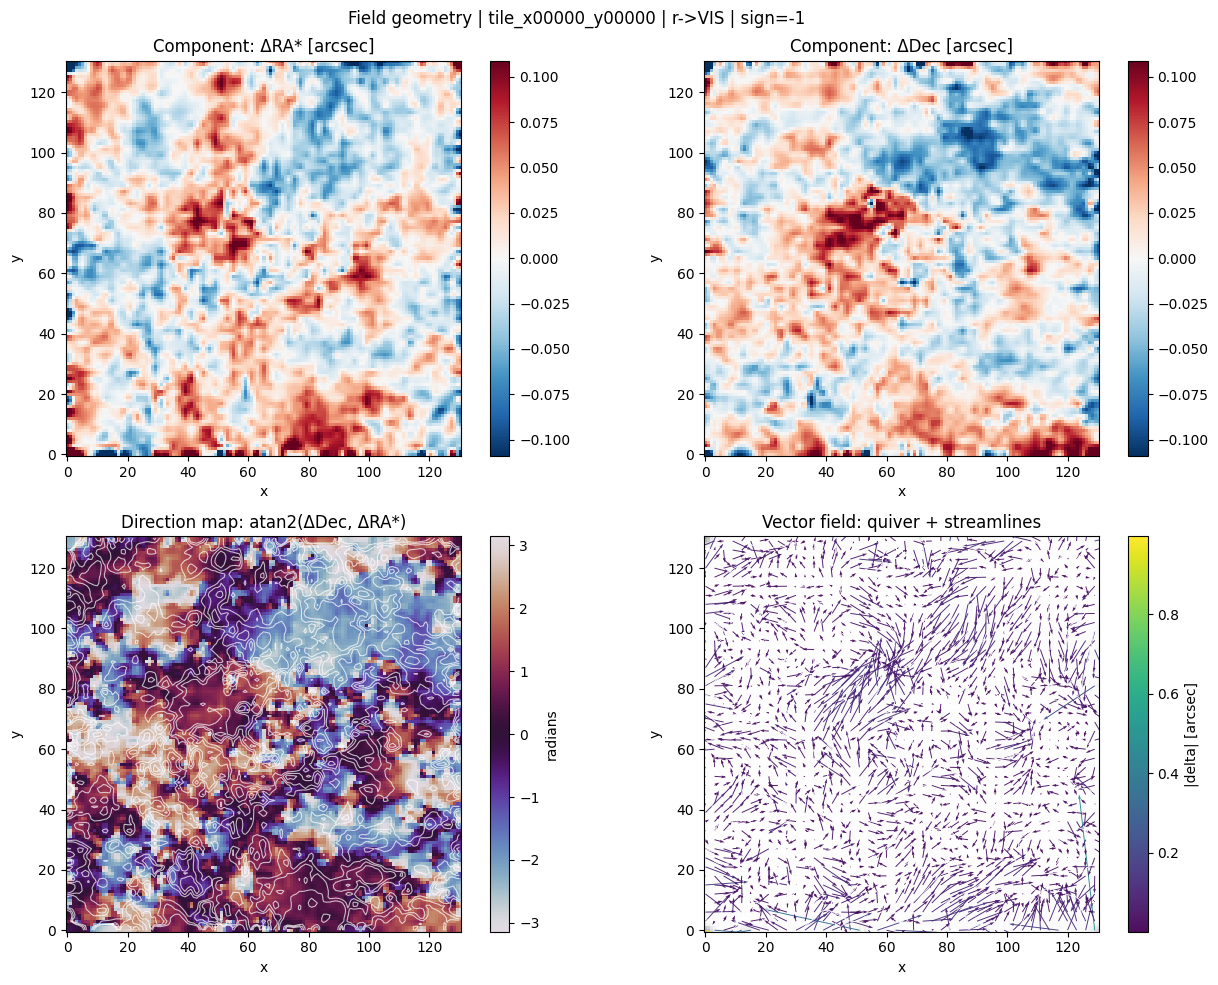

In [17]:
# Field geometry view (shows the fitted 2D function directly)
mag_field = np.hypot(dra_map, dde_map)
ang_field = np.arctan2(dde_map, dra_map)  # -pi..pi

q = float(np.nanpercentile(np.abs(np.concatenate([dra_map.ravel(), dde_map.ravel()])), 99))
q = max(q, 1e-6)

fig, ax = plt.subplots(2, 2, figsize=(13, 10))

im0 = ax[0, 0].imshow(dra_map, cmap='RdBu_r', vmin=-q, vmax=q)
ax[0, 0].set_title('Component: ΔRA* [arcsec]')
plt.colorbar(im0, ax=ax[0, 0], fraction=0.046)

im1 = ax[0, 1].imshow(dde_map, cmap='RdBu_r', vmin=-q, vmax=q)
ax[0, 1].set_title('Component: ΔDec [arcsec]')
plt.colorbar(im1, ax=ax[0, 1], fraction=0.046)

im2 = ax[1, 0].imshow(ang_field, cmap='twilight', vmin=-np.pi, vmax=np.pi)
levels = np.nanpercentile(mag_field, [50, 75, 90]) if np.isfinite(mag_field).any() else []
if len(levels):
    ax[1, 0].contour(mag_field, levels=levels, colors='white', linewidths=0.8, alpha=0.7)
ax[1, 0].set_title('Direction map: atan2(ΔDec, ΔRA*)')
cb2 = plt.colorbar(im2, ax=ax[1, 0], fraction=0.046)
cb2.set_label('radians')

step = max(1, min(dra_map.shape) // 40)
yy, xx = np.mgrid[0:dra_map.shape[0]:step, 0:dra_map.shape[1]:step]
u = dra_map[::step, ::step]
v = dde_map[::step, ::step]
vmag = np.hypot(u, v)

ax[1, 1].imshow(mag_field, cmap='Greys', alpha=0.35)
if np.isfinite(vmag).any() and np.nanmax(vmag) > 0:
    q90 = float(np.nanpercentile(vmag, 90))
    qscale = max(q90 / 8.0, 1e-6)
else:
    qscale = 1.0
qv = ax[1, 1].quiver(
    xx, yy, u, v, vmag,
    cmap='viridis',
    angles='xy',
    scale_units='xy',
    scale=qscale,
    alpha=0.95,
)
try:
    yfull = np.arange(dra_map.shape[0])
    xfull = np.arange(dra_map.shape[1])
    ax[1, 1].streamplot(xfull, yfull, dra_map, dde_map, color='white', density=1.0, linewidth=0.6, arrowsize=0.7)
except Exception:
    pass
ax[1, 1].set_title('Vector field: quiver + streamlines')
plt.colorbar(qv, ax=ax[1, 1], fraction=0.046, label='|delta| [arcsec]')

for a in ax.ravel():
    a.set_xlabel('x')
    a.set_ylabel('y')

fig.suptitle(f'Field geometry | {TILE_ID} | {RUBIN_BAND}->{EUCLID_BAND} | sign={ACTIVE_SIGN:+.0f}', y=0.98)
plt.tight_layout()
plt.show()


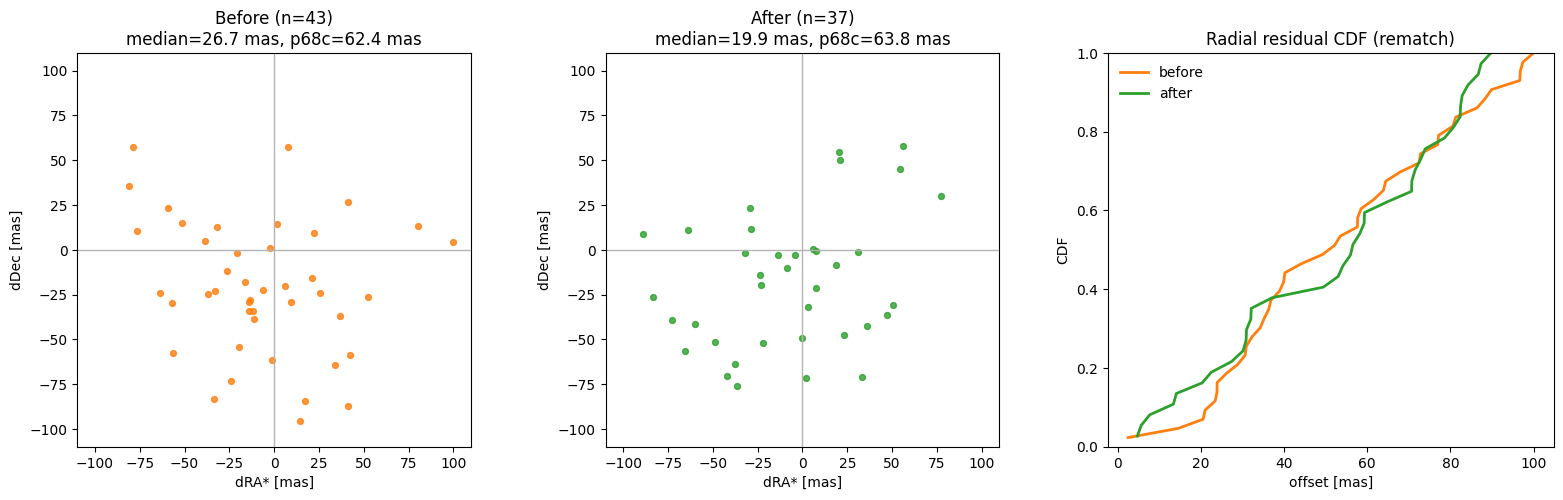

In [18]:
# Matched residuals before vs after (active sign)
fig, ax = plt.subplots(1, 3, figsize=(16, 5))
lim = 1.1 * max(
    20.0,
    float(np.nanmax(np.abs(dra_b))) if dra_b.size else 0.0,
    float(np.nanmax(np.abs(ddec_b))) if ddec_b.size else 0.0,
    float(np.nanmax(np.abs(dra_a))) if dra_a.size else 0.0,
    float(np.nanmax(np.abs(ddec_a))) if ddec_a.size else 0.0,
)

b = baseline['clipped']
a = active['rematch']['clipped']
ax[0].scatter(dra_b, ddec_b, s=18, alpha=0.8, color='tab:orange')
ax[0].axhline(0, color='0.7', lw=1); ax[0].axvline(0, color='0.7', lw=1)
ax[0].set_title(f"Before (n={baseline['all']['n']})\nmedian={b['median']:.1f} mas, p68c={b['p68c']:.1f} mas")
ax[0].set_xlabel('dRA* [mas]'); ax[0].set_ylabel('dDec [mas]')
ax[0].set_xlim(-lim, lim); ax[0].set_ylim(-lim, lim); ax[0].set_aspect('equal', 'box')

ax[1].scatter(dra_a, ddec_a, s=18, alpha=0.8, color='tab:green')
ax[1].axhline(0, color='0.7', lw=1); ax[1].axvline(0, color='0.7', lw=1)
ax[1].set_title(f"After (n={active['rematch']['all']['n']})\nmedian={a['median']:.1f} mas, p68c={a['p68c']:.1f} mas")
ax[1].set_xlabel('dRA* [mas]'); ax[1].set_ylabel('dDec [mas]')
ax[1].set_xlim(-lim, lim); ax[1].set_ylim(-lim, lim); ax[1].set_aspect('equal', 'box')

if r_b.size:
    xb = np.sort(r_b); yb = np.arange(1, len(xb) + 1) / len(xb)
    ax[2].plot(xb, yb, lw=2, color='tab:orange', label='before')
if r_a.size:
    xa = np.sort(r_a); ya = np.arange(1, len(xa) + 1) / len(xa)
    ax[2].plot(xa, ya, lw=2, color='tab:green', label='after')
ax[2].set_title('Radial residual CDF (rematch)')
ax[2].set_xlabel('offset [mas]'); ax[2].set_ylabel('CDF')
ax[2].set_ylim(0, 1.0); ax[2].legend(frameon=False)

plt.tight_layout()
plt.show()


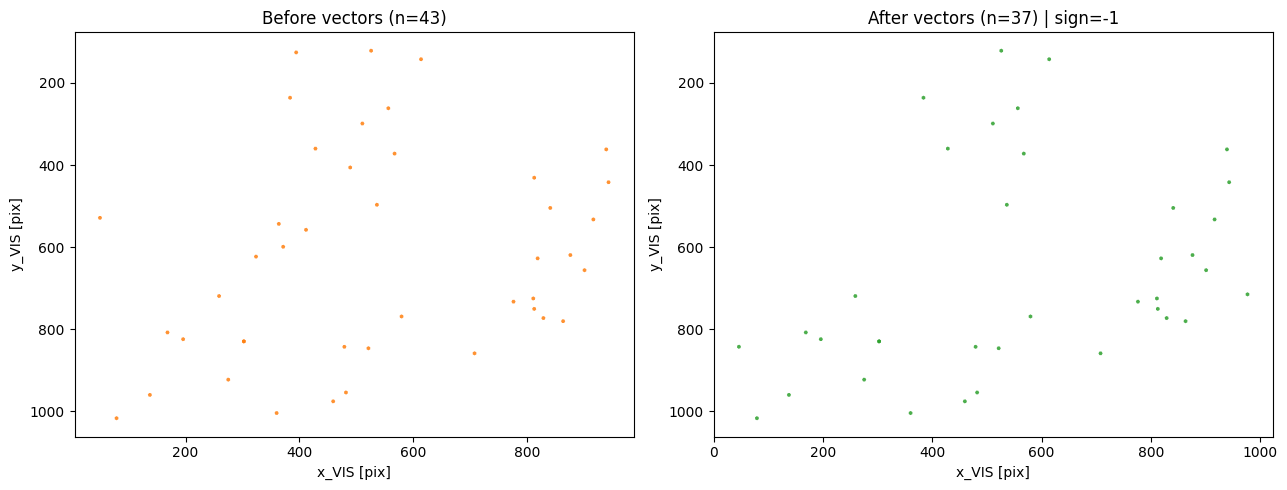

In [19]:
# Residual vectors in VIS pixel space (rematch)
fig, ax = plt.subplots(1, 2, figsize=(13, 5))

if len(ci_b):
    ax[0].quiver(cand_x[ci_b], cand_y[ci_b], dra_b, ddec_b, angles='xy', scale_units='xy', scale=250, color='tab:orange', alpha=0.85)
ax[0].set_title(f'Before vectors (n={len(ci_b)})')
ax[0].set_xlabel('x_VIS [pix]'); ax[0].set_ylabel('y_VIS [pix]'); ax[0].invert_yaxis()

if len(ci_a):
    ax[1].quiver(cand_x[ci_a], cand_y[ci_a], dra_a, ddec_a, angles='xy', scale_units='xy', scale=250, color='tab:green', alpha=0.85)
ax[1].set_title(f'After vectors (n={len(ci_a)}) | sign={ACTIVE_SIGN:+.0f}')
ax[1].set_xlabel('x_VIS [pix]'); ax[1].set_ylabel('y_VIS [pix]'); ax[1].invert_yaxis()

plt.tight_layout()
plt.show()


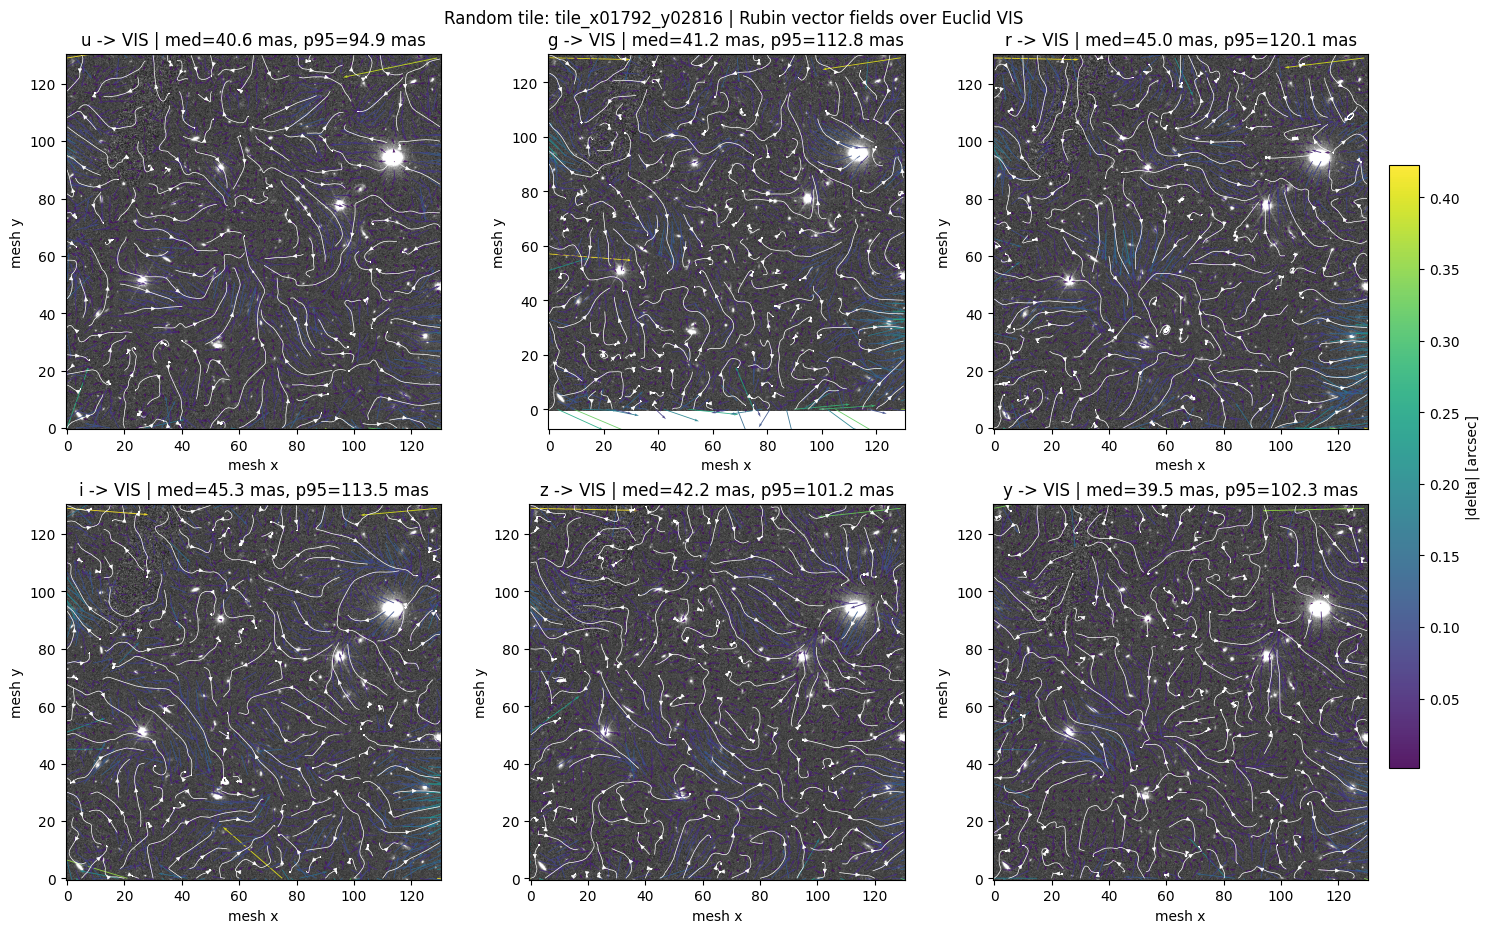

In [20]:
# Random tile: Rubin u/g/r/i/z/y vector fields on Euclid VIS background (2x3)
rng = np.random.default_rng(41)
bands = ['u', 'g', 'r', 'i', 'z', 'y']

with fits.open(FITS_PATH) as hdul:
    available = set()
    for hdu in hdul[1:]:
        parts = hdu.name.lower().split('.')
        if len(parts) != 3:
            continue
        tile, band, kind = parts
        if band in bands and kind in ('dra', 'dde'):
            available.add((tile, band, kind))

    # Tiles that have all six bands with both DRA and DDE.
    full_tiles = []
    for tile in sorted({t for t, _, _ in available}):
        ok = True
        for b in bands:
            if (tile, b, 'dra') not in available or (tile, b, 'dde') not in available:
                ok = False
                break
        if ok:
            full_tiles.append(tile)

    if full_tiles:
        tile_pick = rng.choice(full_tiles)
    else:
        tile_scores = {}
        for tile in sorted({t for t, _, _ in available}):
            score = 0
            for b in bands:
                if (tile, b, 'dra') in available and (tile, b, 'dde') in available:
                    score += 1
            tile_scores[tile] = score
        tile_pick = max(tile_scores, key=tile_scores.get)

    fields = {}
    mags = []
    map_shape = None
    for b in bands:
        try:
            dra, _ = _get_hdu_data_by_name(hdul, f'{tile_pick}.{b}.DRA')
            dde, _ = _get_hdu_data_by_name(hdul, f'{tile_pick}.{b}.DDE')
        except Exception:
            fields[b] = None
            continue
        mag = np.hypot(dra, dde)
        fields[b] = {'dra': dra, 'dde': dde, 'mag': mag}
        mags.append(mag)
        map_shape = dra.shape

# Load Euclid VIS image for context and scale it robustly.
euclid_npz = REPO_ROOT / f'data/euclid_tiles_ecdfs/{tile_pick}_euclid.npz'
vis_img = None
if euclid_npz.exists():
    try:
        d = np.load(euclid_npz, allow_pickle=False)
        if 'img_VIS' in d:
            vis_img = np.asarray(d['img_VIS'], dtype=float)
    except Exception:
        vis_img = None

if vis_img is None:
    vis_img = np.zeros(map_shape if map_shape is not None else (256, 256), dtype=float)

valid_vis = np.isfinite(vis_img)
if np.any(valid_vis):
    vv = vis_img[valid_vis]
    vis_vmin = float(np.nanpercentile(vv, 1.0))
    vis_vmax = float(np.nanpercentile(vv, 99.5))
    if (not np.isfinite(vis_vmin)) or (not np.isfinite(vis_vmax)) or (vis_vmax <= vis_vmin):
        med = float(np.nanmedian(vv))
        mad = float(np.nanmedian(np.abs(vv - med)))
        sig = 1.4826 * mad if mad > 0 else float(np.nanstd(vv))
        vis_vmin = med - 2.0 * sig
        vis_vmax = med + 5.0 * sig
else:
    vis_vmin, vis_vmax = -1.0, 1.0

if mags:
    mag_vmax = float(np.nanpercentile(np.concatenate([m.ravel() for m in mags]), 99))
    mag_vmax = max(mag_vmax, 1e-6)
else:
    mag_vmax = 1e-3

fig, ax = plt.subplots(2, 3, figsize=(15, 9), constrained_layout=True)
q_handle = None
for i, b in enumerate(bands):
    a = ax.flat[i]
    fld = fields.get(b)
    if fld is None:
        a.axis('off')
        a.set_title(f'{b}: missing')
        continue

    dra = fld['dra']
    dde = fld['dde']
    mag = fld['mag']
    h, w = dra.shape

    # Show VIS in the same coordinate system as the mesh map.
    a.imshow(
        vis_img,
        cmap='gray',
        vmin=vis_vmin,
        vmax=vis_vmax,
        extent=[-0.5, w - 0.5, -0.5, h - 0.5],
        alpha=0.95,
    )

    step = max(1, min(h, w) // 36)
    yy, xx = np.mgrid[0:h:step, 0:w:step]
    u = dra[::step, ::step]
    v = dde[::step, ::step]
    qv = np.hypot(u, v)

    if np.isfinite(qv).any() and np.nanmax(qv) > 0:
        q90 = float(np.nanpercentile(qv, 90))
        qscale = max(q90 / 7.0, 1e-6)
    else:
        qscale = 1.0

    q = a.quiver(
        xx,
        yy,
        u,
        v,
        qv,
        cmap='viridis',
        angles='xy',
        scale_units='xy',
        scale=qscale,
        alpha=0.9,
        linewidth=0.3,
    )
    if q_handle is None:
        q_handle = q

    try:
        yfull = np.arange(h)
        xfull = np.arange(w)
        a.streamplot(xfull, yfull, dra, dde, color='white', density=0.9, linewidth=0.5, arrowsize=0.6)
    except Exception:
        pass

    med = float(np.nanmedian(mag) * 1000.0)
    p95 = float(np.nanpercentile(mag, 95) * 1000.0)
    a.set_title(f'{b} -> VIS | med={med:.1f} mas, p95={p95:.1f} mas')
    a.set_xlabel('mesh x')
    a.set_ylabel('mesh y')

if q_handle is not None:
    cbar = fig.colorbar(q_handle, ax=ax.ravel().tolist(), fraction=0.022, pad=0.015)
    cbar.set_label('|delta| [arcsec]')

fig.suptitle(f'Random tile: {tile_pick} | Rubin vector fields over Euclid VIS', y=1.02)
plt.show()
